# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** Paulus Titto Dermawan
- **Email:** paulustito555@student.uns.ac.id
- **ID Dicoding:** ptitto

## Import Semua Packages/Library yang Digunakan

In [1]:
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm as tq

# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

In [2]:
# Import for processing images
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize, rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [3]:
# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# Import Librarys for create and evaluate model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

## Data Preparation

### Data Loading

In [5]:
# Import module yang disediakan google colab untuk kebutuhan upload file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"devbytoo","key":"e8bd7fb9a19cbbab216d7e567b8865c9"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d gpiosenka/coffee-bean-dataset-resized-224-x-224
!unzip coffee-bean-dataset-resized-224-x-224.zip

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/coffee-bean-dataset-resized-224-x-224
License(s): CC-BY-SA-4.0
Archive:  coffee-bean-dataset-resized-224-x-224.zip
  inflating: Coffee Bean.csv         
  inflating: test/Dark/dark (1).png  
  inflating: test/Dark/dark (10).png  
  inflating: test/Dark/dark (100).png  
  inflating: test/Dark/dark (11).png  
  inflating: test/Dark/dark (12).png  
  inflating: test/Dark/dark (13).png  
  inflating: test/Dark/dark (14).png  
  inflating: test/Dark/dark (15).png  
  inflating: test/Dark/dark (16).png  
  inflating: test/Dark/dark (17).png  
  inflating: test/Dark/dark (18).png  
  inflating: test/Dark/dark (19).png  
  inflating: test/Dark/dark (2).png  
  inflating: test/Dark/dark (20).png  
  inflating: test/Dark/dark (21).png  
  inflating: test/Dark/dark (22).png  
  inflating: test/Dark/dark (23).png  
  inflating: test/Dark/dark (24).png  
  inflating: test/Dark/dark (25).png  
  inflating: test/Dark/dark (26).png  
  inflating: 

### Data Preprocessing

In [8]:
import os
import shutil

train_dir = "train"
test_dir = "test"

combined_dir = "coffee-bean/dataset"

os.makedirs(combined_dir, exist_ok=True)

In [9]:
# Salin file ke foldee dari train
for category in os.listdir(train_dir):
  category_dir = os.path.join(train_dir, category)
  if os.path.isdir(category_dir):
    shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

In [10]:
# Salin file ke foldee dari train
for category in os.listdir(test_dir):
  category_dir = os.path.join(test_dir, category)
  if os.path.isdir(category_dir):
    shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

In [11]:
coffee_bean = {}

# Tentukan path sumber train
path = "coffee-bean/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    coffee_bean[i] = os.listdir(os.path.join(path_sub, i))

In [12]:
print(coffee_bean)

{'Medium': ['medium (274).png', 'medium (122).png', 'medium (156).png', 'medium (191).png', 'medium (28).png', 'medium (3).png', 'medium (62).png', 'medium (299).png', 'medium (120).png', 'medium (39).png', 'medium (136).png', 'medium (160).png', 'medium (248).png', 'medium (200).png', 'medium (22).png', 'medium (159).png', 'medium (195).png', 'medium (180).png', 'medium (46).png', 'medium (53).png', 'medium (130).png', 'medium (295).png', 'medium (124).png', 'medium (217).png', 'medium (222).png', 'medium (20).png', 'medium (154).png', 'medium (13).png', 'medium (229).png', 'medium (127).png', 'medium (80).png', 'medium (114).png', 'medium (157).png', 'medium (179).png', 'medium (183).png', 'medium (52).png', 'medium (181).png', 'medium (212).png', 'medium (27).png', 'medium (85).png', 'medium (261).png', 'medium (189).png', 'medium (68).png', 'medium (186).png', 'medium (204).png', 'medium (32).png', 'medium (140).png', 'medium (109).png', 'medium (2).png', 'medium (172).png', 'mediu

In [13]:
import numpy as np

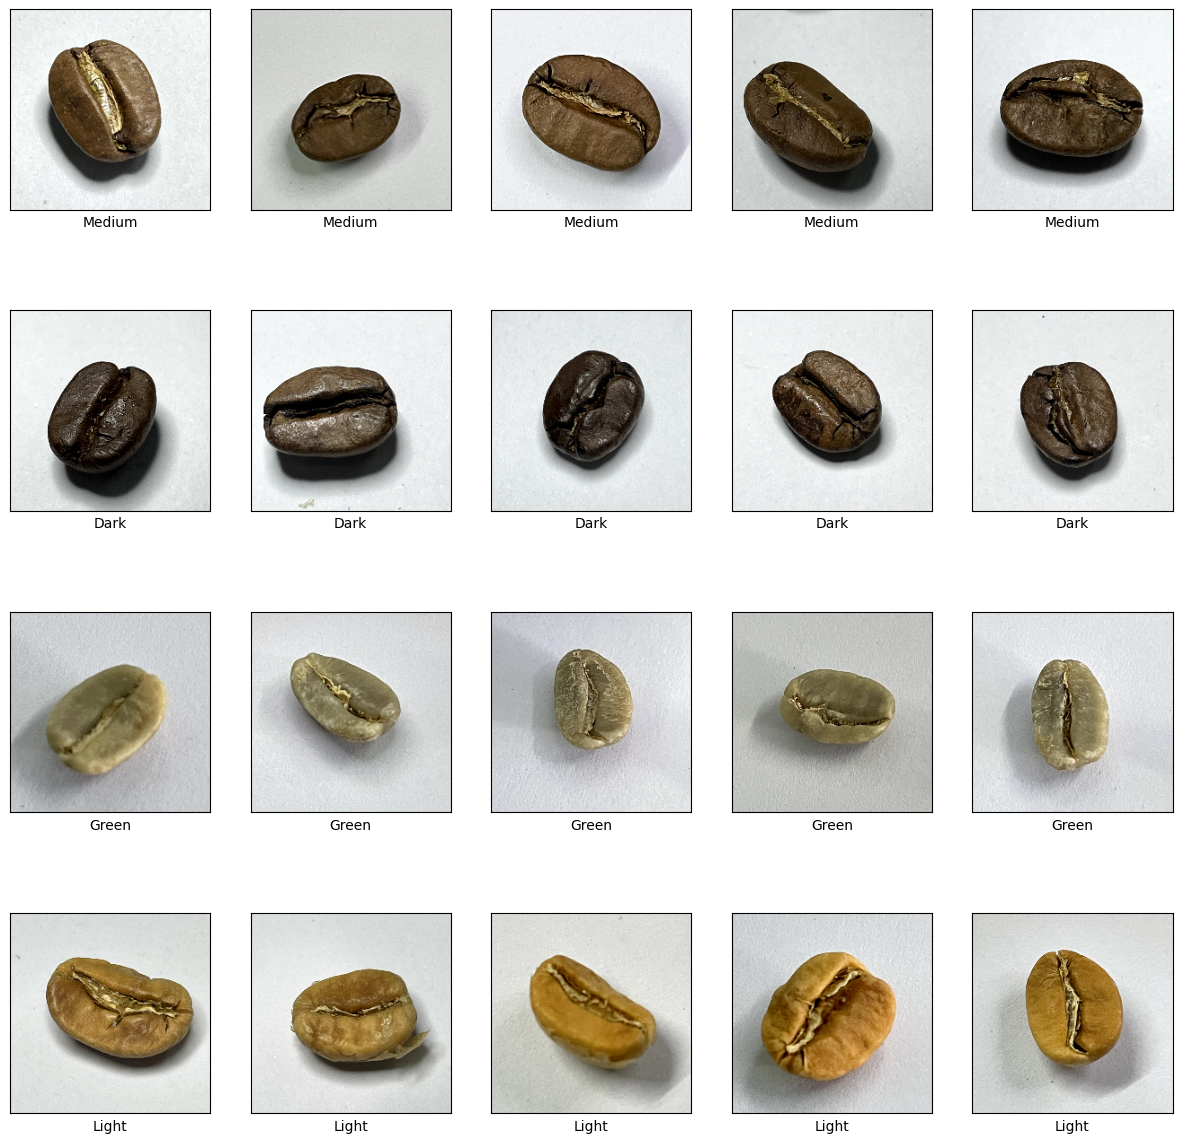

In [14]:
path_sub = "coffee-bean/dataset"


fig, axs = plt.subplots(len(coffee_bean.keys()), 5, figsize=(15,15))

for i, class_name in enumerate(os.listdir(path_sub)):
  images = np.random.choice(coffee_bean[class_name], 5, replace=False)

  for j, image_name in enumerate(images):
    img_path = os.path.join(path_sub, class_name, image_name)
    img = Image.open(img_path)
    # img = Image.open(img_path).convert("L")
    axs[i,j].imshow(img)
    # axs[i,j].imshow(img, cmap="gray")
    axs[i,j].set(xlabel=class_name, xticks=[], yticks=[])

In [15]:
coffee_bean__path = "coffee-bean/dataset/"

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(coffee_bean__path):
  for name in files:
    full_path.append(os.path.join(path, name))
    labels.append(path.split("/")[-1])
    file_name.append(name)

print(full_path[0])
print(labels[0])
print(file_name[0])

coffee-bean/dataset/Medium/medium (274).png
Medium
medium (274).png


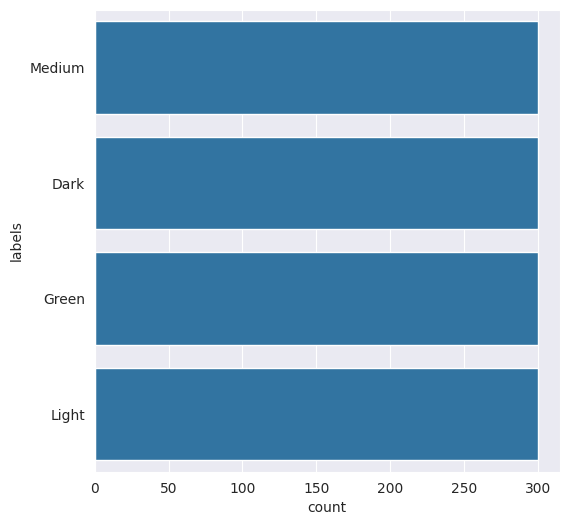

In [16]:
distributon_train = pd.DataFrame({
    "path": full_path,
    "labels": labels,
    "file_name": file_name
})

Label = distributon_train["labels"]
plt.figure(figsize=(6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [17]:
#  Create function for rotate againt the clock time

def anticlockwise_rotation(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  sudut = random.randint(0, 180)
  return rotate(img, sudut)

# Create function for rotate clock wise
def clockwise_rotation(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  sudut = random.randint(0, 180)
  return rotate(img, -sudut)


# Function Flip images
def flip_up_down(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  return np.flipud(img)

# Function add brightness
def add_brightness(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  img = adjust_gamma(img, gamma=1.5, gain=1)
  return img

# Function for Bluring
def blur_image(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  return cv2.GaussianBlur(img, (9,9), 0)

# Function given effect
def sheared(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224,224))
  transform = AffineTransform(shear=0.3)
  shear_image = warp(img, transform)
  return shear_image

# Function for noise
def noise(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  return random_noise(img)

# Function add warp_shift
def warp_shift(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  transform = AffineTransform(translation=(0, 40))
  warp_image = warp(img, transform, mode="wrap")
  return warp_image

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np


In [19]:
transformations = {
    'rotate anticlockwise': anticlockwise_rotation,
    'rotate clockwise': clockwise_rotation,
    'warp shift': warp_shift,
    'blurring image': blur_image,
    'add brightness': add_brightness,
    'flip up down': flip_up_down,
    'shear image': sheared
}

images_path = "coffee-bean/dataset/Dark"
augmented_path = "coffee-bean/dataset/Dark_augmented"



def augment_data(images_path, augmented_path):
  if not os.path.exists(augmented_path):
    os.makedirs(augmented_path)

  images = []  # To save images that have been preprocessed from the folder

  # Baca nama gambar dari folder dan tambahkan path ke dalam array "images"
  for im in os.listdir(images_path):
      images.append(os.path.join(images_path, im))

  # Jumlah gambar yang akan ditambahkan dengan hasil transformasi augmentasi
  images_to_generate = 700
  i = 1

  while i <= images_to_generate:
      image = random.choice(images)
      try:
          original_image = io.imread(image)

          # Memeriksa apakah gambar memiliki dimensi yang valid (3 atau 4 dimensi)
          if original_image.ndim not in [3, 4]:
              raise ValueError('Invalid image dimensions')

          transformed_image = None
          n = 0  # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
          transformation_count = random.randint(1, len(transformations))  # Pilih jumlah transformasi acak yang akan diterapkan pada gambar

          while n <= transformation_count:
              key = random.choice(list(transformations))  # Secara acak memilih dan memanggil metode
              transformed_image = transformations[key](original_image)
              n = n + 1

          new_image_path = "%s/augmented_image_%s.jpg" % (augmented_path, i)
          transformed_image = img_as_ubyte(transformed_image)  # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
          cv2.imwrite(new_image_path, transformed_image)  # Simpan hasil transformasi augmentasi pada gambar ke path yang ditentukan
          i = i + 1
      except ValueError as e:
          print('Could not read or process the image', image, ':', e, 'hence skipping it.')


In [20]:
augment_data("coffee-bean/dataset/Dark","coffee-bean/dataset/Dark_augmented")
augment_data("coffee-bean/dataset/Light","coffee-bean/dataset/Light_augmented")
augment_data("coffee-bean/dataset/Green","coffee-bean/dataset/Green_augmented")
augment_data("coffee-bean/dataset/Medium","coffee-bean/dataset/Medium_augmented")

In [21]:
!cp -r coffee-bean/dataset/Dark_augmented/* coffee-bean/dataset/Dark/
!cp -r coffee-bean/dataset/Light_augmented/* coffee-bean/dataset/Light/
!cp -r coffee-bean/dataset/Green_augmented/* coffee-bean/dataset/Green/
!cp -r coffee-bean/dataset/Medium_augmented/* coffee-bean/dataset/Medium/

In [22]:
!rm -r coffee-bean/dataset/Dark_augmented/
!rm -r coffee-bean/dataset/Light_augmented/
!rm -r coffee-bean/dataset/Green_augmented/
!rm -r coffee-bean/dataset/Medium_augmented/

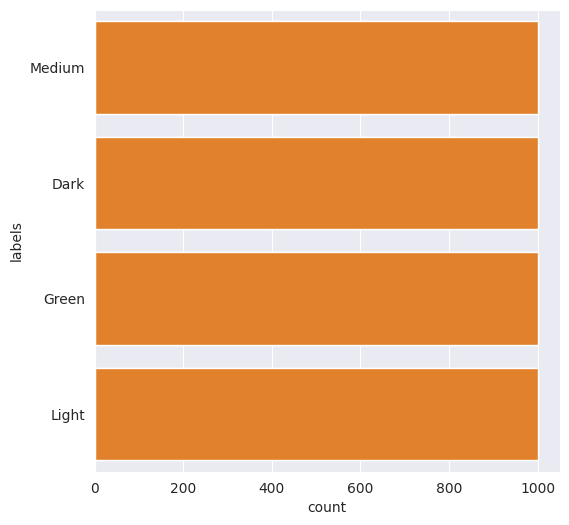

In [23]:
coffee_path = "coffee-bean/dataset/"

file_name = []
labels = []
full_path = []


for path, subdirs, files in os.walk(coffee_path):
  for name in files:
    full_path.append(os.path.join(path, name))
    labels.append(path.split("/")[-1])
    file_name.append(name)

distribution_train = pd.DataFrame({
    "path":full_path,
    "file_name":file_name,
    "labels": labels
})

Label = distribution_train["labels"]
plt.figure(figsize= (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [24]:
mypath = "coffee-bean/dataset/"
file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(mypath):
  for name in files:
    full_path.append(os.path.join(path, name))
    labels.append(path.split("/")[-1])
    file_name.append(name)


In [25]:
df = pd.DataFrame({
    "path":full_path,
    "file_name": file_name,
    "labels": labels
})

In [26]:
df.groupby(["labels"]).size()

,0
labels,
Dark,1000
Green,1000
Light,1000
Medium,1000


In [27]:
df.head()

,path,file_name,labels
0,coffee-bean/dataset/Medium/augmented_image_119...,augmented_image_119.jpg,Medium
1,coffee-bean/dataset/Medium/augmented_image_194...,augmented_image_194.jpg,Medium
2,coffee-bean/dataset/Medium/augmented_image_383...,augmented_image_383.jpg,Medium
3,coffee-bean/dataset/Medium/medium (274).png,medium (274).png,Medium
4,coffee-bean/dataset/Medium/augmented_image_51.jpg,augmented_image_51.jpg,Medium


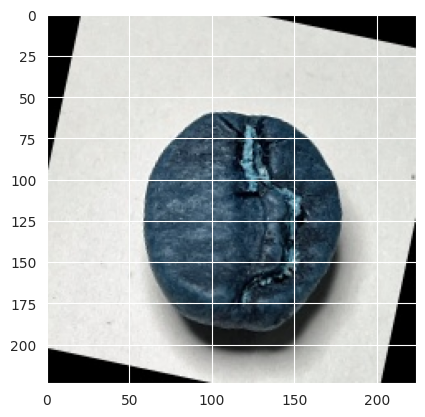

In [28]:
plt.imshow(imread(df["path"][0]))

#### Split Dataset

In [29]:
X = df["path"]
y = df["labels"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
X.head(5)

,path
0,coffee-bean/dataset/Medium/augmented_image_119...
1,coffee-bean/dataset/Medium/augmented_image_194...
2,coffee-bean/dataset/Medium/augmented_image_383...
3,coffee-bean/dataset/Medium/medium (274).png
4,coffee-bean/dataset/Medium/augmented_image_51.jpg


In [31]:
y.value_counts()

,count
labels,
Medium,1000
Dark,1000
Green,1000
Light,1000


In [32]:
df_tr = pd.DataFrame({
    "path": X_train,
    "labels": y_train,
    "set":"train"
})
df_tr.head()

,path,labels,set
3994,coffee-bean/dataset/Light/augmented_image_486.jpg,Light,train
423,coffee-bean/dataset/Medium/augmented_image_175...,Medium,train
2991,coffee-bean/dataset/Green/augmented_image_696.jpg,Green,train
1221,coffee-bean/dataset/Dark/augmented_image_570.jpg,Dark,train
506,coffee-bean/dataset/Medium/augmented_image_259...,Medium,train


In [33]:
df_te = pd.DataFrame({
    "path":X_test,
    "labels": y_test,
    "set":"test"
})
df_te.head()

,path,labels,set
555,coffee-bean/dataset/Medium/augmented_image_242...,Medium,test
3491,coffee-bean/dataset/Light/augmented_image_674.jpg,Light,test
527,coffee-bean/dataset/Medium/medium (67).png,Medium,test
3925,coffee-bean/dataset/Light/light (277).png,Light,test
2989,coffee-bean/dataset/Green/augmented_image_470.jpg,Green,test


In [34]:
import pandas as pd

df_all = pd.concat([df_tr, df_te], ignore_index=True)
print("============================================ \n")
print(df_all.groupby(["labels", "set"]).size(), "\n")

print("============================================ \n")

print(df_all.sample(5))


labels  set  
Dark    test     213
        train    787
Green   test     194
        train    806
Light   test     184
        train    816
Medium  test     209
        train    791
dtype: int64 


                                                   path  labels    set
3772          coffee-bean/dataset/Light/light (184).png   Light   test
750    coffee-bean/dataset/Dark/augmented_image_555.jpg    Dark  train
2809  coffee-bean/dataset/Medium/augmented_image_459...  Medium  train
2549  coffee-bean/dataset/Green/augmented_image_663.jpg   Green  train
3319  coffee-bean/dataset/Light/augmented_image_677.jpg   Light   test


In [35]:
datasource_path = "coffee-bean/dataset/"
dataset_path = "Dataset-Final/"


for index, row in tq(df_all.iterrows()):
  file_path = row["path"]
  if os.path.exists(file_path) == False:
    file_path = os.path.join(
        datasource_path,
        row["labels"],
        row["image"].split(".")[0]
    )

  if os.path.exists(os.path.join(dataset_path, row["set"], row["labels"])) == False:
    os.makedirs(os.path.join(dataset_path, row["set"], row["labels"]))


  destination_file_name = file_path.split("/")[-1]
  file_dest = os.path.join(dataset_path, row["set"], row["labels"], destination_file_name)
  if os.path.exists(file_dest)==False:
    shutil.copy2(file_path, file_dest)

0it [00:00, ?it/s]

In [36]:
TRAIN_DIR = "Dataset-Final/train"
TEST_DIR = "Dataset-Final/test"

train_dark = os.path.join(TRAIN_DIR, "Dark")
train_green = os.path.join(TRAIN_DIR, "Green")
train_light = os.path.join(TRAIN_DIR, "Light")
train_medium = os.path.join(TRAIN_DIR, "Medium")

test_dark = os.path.join(TEST_DIR, "Dark")
test_green = os.path.join(TEST_DIR, "Green")
test_light = os.path.join(TEST_DIR, "Light")
test_medium = os.path.join(TEST_DIR, "Medium")

print("Train Dark: ", len(os.listdir(train_dark)))
print("Train Green: ", len(os.listdir(train_green)))
print("Train Light: ", len(os.listdir(train_light)))
print("Train Medium: ", len(os.listdir(train_medium)))

print("Test Dark: ", len(os.listdir(test_dark)))
print("Test Green: ", len(os.listdir(test_green)))
print("Test Light: ", len(os.listdir(test_light)))
print("Test Medium: ", len(os.listdir(test_medium)))

Train Dark:  787
Train Green:  806
Train Light:  816
Train Medium:  791
Test Dark:  213
Test Green:  194
Test Light:  184
Test Medium:  209


## Modelling

In [37]:
datagen = ImageDataGenerator(rescale=1./255.,
                             validation_split=0.2)

test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=32,
    target_size=(150,150),
    color_mode="grayscale",
    class_mode="binary",
    subset="training",
    shuffle=True
)
validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                color_mode="grayscale",
                                                   class_mode='binary',
                                                   subset='validation',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='binary',
                                                  shuffle=False)


Found 2561 images belonging to 4 classes.
Found 639 images belonging to 4 classes.
Found 800 images belonging to 4 classes.


In [38]:
count_dark, count_green, count_light,count_medium  = len(os.listdir(train_dark)), len(os.listdir(train_green)), len(os.listdir(train_light)), len(os.listdir(train_medium))
weight_0 = (1 / count_dark) * (count_green + count_light + count_medium) / 4.0
weight_1 = (1 / count_green) * (count_dark + count_light + count_medium) / 4.0
weight_2 = (1 / count_light) * (count_dark + count_green + count_medium) / 4.0
weight_3 = (1 / count_medium) * (count_dark + count_green + count_light) / 4.0

class_weights = {0: weight_0, 1: weight_1, 2: weight_2, 3: weight_3}




In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

# Building the model
model = Sequential()
# 3 convolutional layers
model.add(Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(150,150,1)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# 2 hidden layers
model.add(Flatten())
model.add(Dense(128))
model.add(Activation("relu"))

model.add(Dense(128))
model.add(Activation("relu"))

# The output layer with 4 neurons, for 4 classes
model.add(Dense(4))
model.add(Activation("softmax"))

model.compile(loss="sparse_categorical_crossentropy",
                optimizer="adam",
                metrics=["accuracy"])
print(model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 73, 73, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,440,388 (9.31 MB)

 Trainable params: 2,440,388 (9.31 MB)

 Non-trainable params: 0 (0.00 B)

None


In [40]:
history = model.fit(
    train_generator,
    epochs=40,
    batch_size=32,
    validation_data = validation_generator,
    class_weight = class_weights,
    validation_split=0.1
)

Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.3631 - loss: 0.9068 - val_accuracy: 0.6119 - val_loss: 0.8301
Epoch 2/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.6365 - loss: 0.5986 - val_accuracy: 0.6182 - val_loss: 0.7873
Epoch 3/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.6847 - loss: 0.5239 - val_accuracy: 0.6792 - val_loss: 0.7152
Epoch 4/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.7561 - loss: 0.4254 - val_accuracy: 0.6948 - val_loss: 0.6421
Epoch 5/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.7920 - loss: 0.3682 - val_accuracy: 0.7637 - val_loss: 0.5392
Epoch 6/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8362 - loss: 0.2995 - val_accuracy: 0.7684 - val_loss: 0.5920
Epoch 7/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8811 - loss: 0.2231 - val_accuracy: 0.8091 - val_loss: 0.4971
Epoch 8/40
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9108 - loss: 0.1660 - val_accuracy: 0.8106 - val_loss: 0

## Evaluasi dan Visualisasi

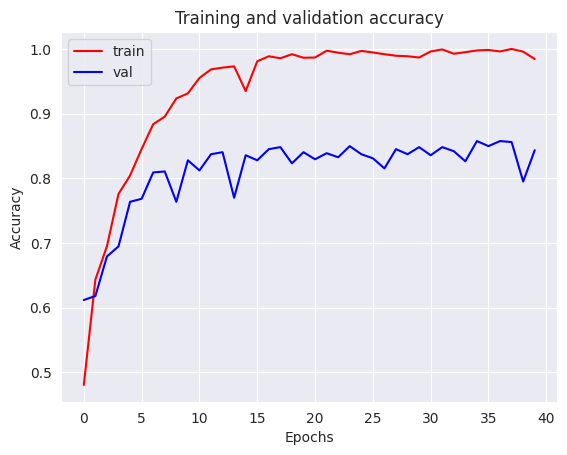

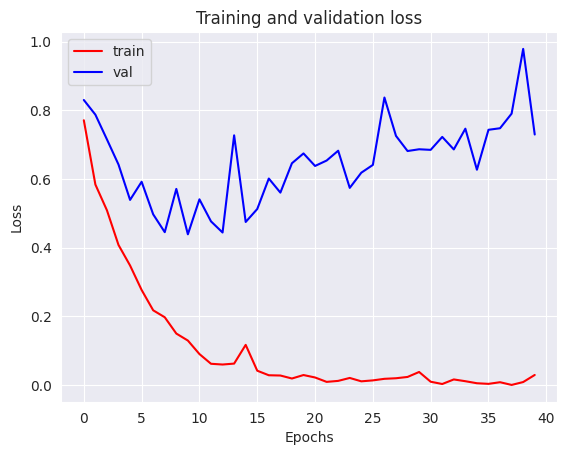

In [41]:
acc_adam = history.history["accuracy"]
val_acc_adam = history.history["val_accuracy"]
loss_adam = history.history["loss"]
val_loss_adam = history.history["val_loss"]

epochs = range(len(acc_adam))

plt.plot(epochs, acc_adam, "r")
plt.plot(epochs, val_acc_adam, "b")
plt.title("Training and validation accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend(["train", "val"], loc="upper left")
plt.show()

plt.plot(epochs, loss_adam, "r")
plt.plot(epochs, val_loss_adam, "b")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend(["train", "val"], loc="upper left")
plt.title("Training and validation loss")
plt.show()

In [42]:
# Evaluasi model terhadap data uji
results = model.evaluate(test_generator, verbose=1)

# Print hasil evaluasi
for metric_name, metric_value in zip(model.metrics_names, results):
    print(f"{metric_name}: {metric_value:.4f}")


800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8558 - loss: 0.7557
loss: 0.6645
compile_metrics: 0.8637


In [43]:
test_generator.reset()
preds_1 = model.predict(test_generator, verbose=0)
preds_1_classes = np.argmax(preds_1, axis=1)

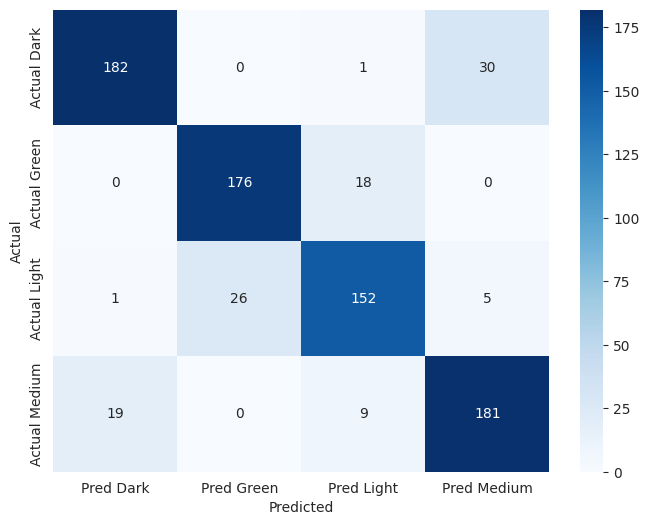

In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Buat confusion matrix
cm = pd.DataFrame(
    confusion_matrix(test_generator.classes, preds_1_classes),
    index=['Actual Dark', 'Actual Green', 'Actual Light', 'Actual Medium'],
    columns=['Pred Dark', 'Pred Green', 'Pred Light', 'Pred Medium']
)

# Visualisasikan
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [45]:
print("\nClassification Report:\n")
print(classification_report(
    y_true=test_generator.classes,
    y_pred=preds_1_classes,
    target_names=['Dark', 'Green', 'Light', 'Medium'],
    digits=4
))


Classification Report:

              precision    recall  f1-score   support

        Dark     0.9010    0.8545    0.8771       213
       Green     0.8713    0.9072    0.8889       194
       Light     0.8444    0.8261    0.8352       184
      Medium     0.8380    0.8660    0.8518       209

    accuracy                         0.8638       800
   macro avg     0.8637    0.8634    0.8632       800
weighted avg     0.8643    0.8638    0.8637       800




### Model

### Predict Dark Coffee Bean


Saving dark (1).png to dark (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
dark (1).png -> Predicted class: Dark


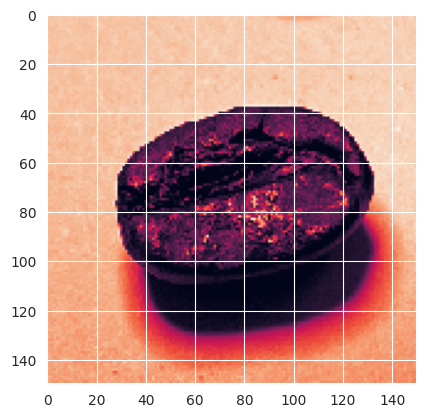

In [46]:
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import files

# Upload gambar
uploaded = files.upload()

# Ambil nama file yang di-upload
for img_path in uploaded.keys():
    # Load dan preprocess gambar
    test_img = image.load_img(img_path, target_size=(150, 150),color_mode='grayscale')
    pp_test_img = image.img_to_array(test_img)
    pp_test_img = pp_test_img/255
    pp_test_img = np.expand_dims(pp_test_img, axis=0)

    # Prediksi
    pred = model.predict(pp_test_img)
    predicted_class = np.argmax(pred)

    # Mapping label
    label_map = {0: 'Dark', 1: 'Green', 2: 'Light', 3: 'Medium'}
    plt.imshow(np.squeeze(pp_test_img))
    print(f"{img_path} -> Predicted class: {label_map[predicted_class]}")


### Predict Light Coffee Bean

Saving light (1).png to light (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
light (1).png -> Predicted class: Light


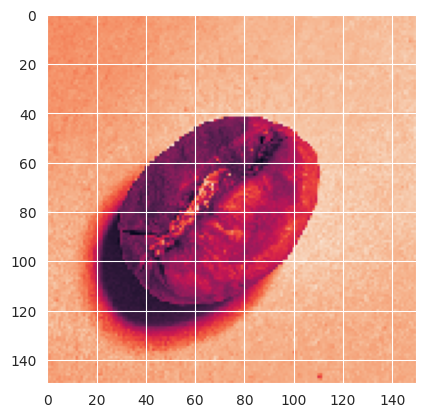

In [47]:
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import files

# Upload gambar
uploaded = files.upload()

# Ambil nama file yang di-upload
for img_path in uploaded.keys():
    # Load dan preprocess gambar
    test_img = image.load_img(img_path, target_size=(150, 150),color_mode='grayscale')
    pp_test_img = image.img_to_array(test_img)
    pp_test_img = pp_test_img/255
    pp_test_img = np.expand_dims(pp_test_img, axis=0)

    # Prediksi
    pred = model.predict(pp_test_img)
    predicted_class = np.argmax(pred)

    # Mapping label
    label_map = {0: 'Dark', 1: 'Green', 2: 'Light', 3: 'Medium'}
    plt.imshow(np.squeeze(pp_test_img))
    print(f"{img_path} -> Predicted class: {label_map[predicted_class]}")


### Predict Medium Coffee Bean

Saving medium (1).png to medium (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
medium (1).png -> Predicted class: Medium


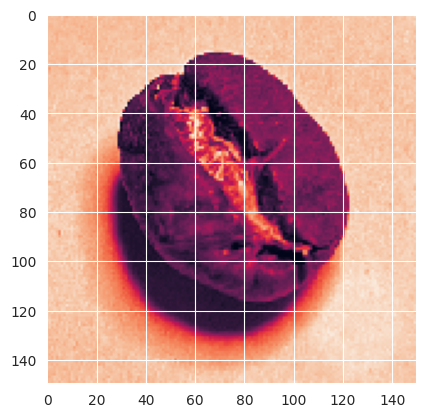

In [48]:
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import files

# Upload gambar
uploaded = files.upload()

# Ambil nama file yang di-upload
for img_path in uploaded.keys():
    # Load dan preprocess gambar
    test_img = image.load_img(img_path, target_size=(150, 150),color_mode='grayscale')
    pp_test_img = image.img_to_array(test_img)
    pp_test_img = pp_test_img/255
    pp_test_img = np.expand_dims(pp_test_img, axis=0)

    # Prediksi
    pred = model.predict(pp_test_img)
    predicted_class = np.argmax(pred)

    # Mapping label
    label_map = {0: 'Dark', 1: 'Green', 2: 'Light', 3: 'Medium'}
    plt.imshow(np.squeeze(pp_test_img))
    print(f"{img_path} -> Predicted class: {label_map[predicted_class]}")


### Predict Green Coffee Bean

Saving green (146).png to green (146).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
green (146).png -> Predicted class: Green


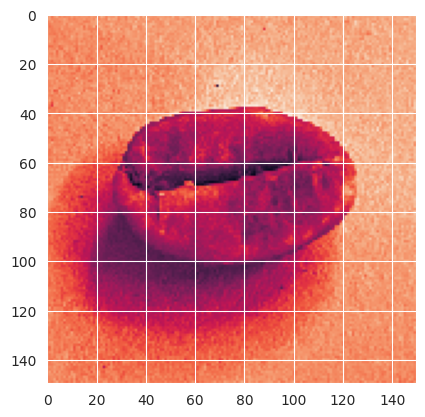

In [49]:
from tensorflow.keras.preprocessing import image
import numpy as np
from google.colab import files

# Upload gambar
uploaded = files.upload()

# Ambil nama file yang di-upload
for img_path in uploaded.keys():
    # Load dan preprocess gambar
    test_img = image.load_img(img_path, target_size=(150, 150),color_mode='grayscale')
    pp_test_img = image.img_to_array(test_img)
    pp_test_img = pp_test_img/255
    pp_test_img = np.expand_dims(pp_test_img, axis=0)

    # Prediksi
    pred = model.predict(pp_test_img)
    predicted_class = np.argmax(pred)

    # Mapping label
    label_map = {0: 'Dark', 1: 'Green', 2: 'Light', 3: 'Medium'}
    plt.imshow(np.squeeze(pp_test_img))
    print(f"{img_path} -> Predicted class: {label_map[predicted_class]}")


## Konversi Model

In [50]:
import tensorflow as tf
import os

### SavedModel format

In [58]:
# model.export("saved_model")

###  Convert ke TFLite

In [59]:
# os.makedirs("tflite", exist_ok=True)

# converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
# tflite_model = converter.convert()

# with open("tflite/model.tflite", "wb") as f:
#     f.write(tflite_model)

# # Simpan label (ganti sesuai label kelas kamu)
# labels = ["Dark", "Green", "Light", "Medium"]
# with open("tflite/label.txt", "w") as f:
#     f.write("\n".join(labels))

In [60]:
# # Install tfjs converter (sekali saja)
# !pip install tensorflowjs

# # Convert SavedModel ke tfjs_model/
# !tensorflowjs_converter --input_format=tf_saved_model \
#                         --output_format=tfjs_graph_model \
#                         saved_model tfjs_model


In [62]:
!rm -r tfjs_model/
!rm -r tflite/
!rm -r saved_model/
!rm -r model.h5

rm: cannot remove 'tfjs_model/': No such file or directory
rm: cannot remove 'tflite/': No such file or directory
rm: cannot remove 'saved_model/': No such file or directory


# Saving Model

In [63]:
model.save("model.h5")

In [64]:
# Install tensorflowjs
!pip install tensorflowjs

# Convert model.h5 to model
!tensorflowjs_converter --input_format=keras model.h5 tfjs_model

2025-05-01 07:28:43.803984: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746084523.823235    5227 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746084523.829304    5227 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
failed to lookup keras version from the file,
    this is likely a weight only file


# Menyimpan pada TensorFlow Lite

In [65]:
# Menyimpan model dalam format SavedModel
export_dir = 'saved_model/'
tf.saved_model.save(model, export_dir)

# Convert SavedModel menjadi coffee-bean.tflite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('coffee-bean.tflite')
tflite_model_file.write_bytes(tflite_model)

8860

In [70]:
!mv coffee-bean.tflite tflite/

In [68]:
!mkdir tflite

In [69]:
labels = ["Dark", "Green", "Light", "Medium"]
with open("tflite/label.txt", "w") as f:
    f.write("\n".join(labels))

# Menyimpan dengan TF-Serving

In [66]:
save_path = os.path.join("models/rps_model/1/")
tf.saved_model.save(model, save_path)

In [73]:
from google.colab import files
import shutil

# Download TFLite model and label
files.download("tflite/coffee-bean.tflite")
files.download("tflite/label.txt")

# Zip TFJS model folder first
shutil.make_archive("tfjs_model", 'zip', "tfjs_model")
files.download("tfjs_model.zip")

# Optional: Zip SavedModel if needed
shutil.make_archive("saved_model", 'zip', "saved_model")
files.download("saved_model.zip")

shutil.make_archive("models", 'zip', "models")
files.download("models.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
!pip freeze > requirements.txt

In [75]:
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Inference (Optional)